### In this file I will be debugging the NN training process

There are several tests that I will go through. We will start with analyzing a NN over 1 frame.

In [1]:
'modules set up'

import os
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

### Analysis over only one frame

- Use the same methodes as the NN training module
- Set up to train over only one frame of data
- Goal is to see if we generalize to the results we found with prior techniques

Diferences are that we are not defining a grid in the differentiation process, where in the frame by frame aproach we where

In [ ]:
'only one frame'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataloader = pre_pro.batching(input, output, workers=4)

In [ ]:
'frame data set'
dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'Network set up'
model_config = (3, 128,524,128)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)


In [ ]:
'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(1500, prints=False, saving=True, save_path= save_path)

In [ ]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
# retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3



In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =5 )

### Just the component from regularization

Here I am going to alter the the method for training the NN in the prepro class. I will check the contribution of both the Regularized portion and the MSE portion of the total loss.

In [ ]:
'reg and mse seperate plot'


network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-3

In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

mse, reg = retrainer.SPT_debugging(500, prints=False, saving= True, save_path='nets/SPT/spt_one_frame.pt', ly =0 )

In [ ]:
plt.hist(mse, bins=50, alpha=0.5, label='MSE')
plt.hist(reg, bins=50, alpha=0.5, label='Regularization')
plt.yscale('log')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.xlim(0,.3)
plt.title(r'$ \alpha = 0$')
plt.legend()
plt.show()

### Just training with regularization

In [ ]:
'SPT training'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

In [ ]:
retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(1000, prints=False, saving= True, save_path='nets/SPT/spt_just_reg.pt', ly =10 )

### Now we will set up a frame shuffler inside of the dataloarder in the prepro class

- Makes the training more evenly dispersed
- More consistent results

In [ ]:
'250 to 350 shuffled'

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


In [ ]:
'checking shuffle'

import cmcrameri.cm as cmc
batch_x, batch_y = next(iter(spt_dataloader))

batch_x = batch_x.reshape(-1, 3)
batch_y = batch_y.reshape(-1, 1)


x = batch_x[:, 0].detach().numpy() 
y = batch_x[:, 1].detach().numpy()  
z = batch_y.detach().numpy().flatten()


fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(x, y, c=z, cmap=cmc.davos, vmin=0, vmax=6, s=8)
plt.xlim(-253, -132)
plt.ylim(-178, -146)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal')


plt.show()


In [ ]:
'training off shuffled data'

'Network set up'
model_config = (3, 524,1024,1024, 524, 524)
net = Net(torch.cos, *model_config).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

'MSE training'
save_path = 'nets/MSE/MSE_one_frame.pt'
trainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader,model_config,optimizer, net )
trainer.MSE_train(500, prints=True, saving=True, save_path= save_path)


In [ ]:
'Adding regularization'

network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 1e-4

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(100, prints=True, saving= True, save_path='nets/SPT/spt_250_350.pt', ly =5 )

### Making Loss curves by epoch

In [2]:
'Training Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [3]:
'Testing Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [4]:
epochs, alpha = [3000, 10]
stopping = -4

loss_curve = 'data/e_100_a_10.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_e_100_a_10.pt', ly =alpha, ver_dataloader = ver_dataloader, stopping_crit =stopping )

torch.save(losses, loss_curve)

Epoch 0, Batch 0, Loss: 3.410776
Epoch 0 Complete - Avg Loss: 1.402035
Epoch 1, Batch 0, Loss: 1.402035
Epoch 1 Complete - Avg Loss: 1.938962
Epoch 2, Batch 0, Loss: 1.938962
Epoch 2 Complete - Avg Loss: 0.934513
Epoch 3, Batch 0, Loss: 0.934513
Epoch 3 Complete - Avg Loss: 1.028117
Epoch 4, Batch 0, Loss: 1.028117
Epoch 4 Complete - Avg Loss: 1.013959
Epoch 5, Batch 0, Loss: 1.013959
Epoch 5 Complete - Avg Loss: 0.858893
Epoch 6, Batch 0, Loss: 0.858893
Epoch 6 Complete - Avg Loss: 0.953656
Epoch 7, Batch 0, Loss: 0.953656
Epoch 7 Complete - Avg Loss: 0.792088
Epoch 8, Batch 0, Loss: 0.792088
Epoch 8 Complete - Avg Loss: 0.855135
Epoch 9, Batch 0, Loss: 0.855135
Epoch 9 Complete - Avg Loss: 0.695300
Epoch 10, Batch 0, Loss: 0.695300
Epoch 10 Complete - Avg Loss: 0.712924
Epoch 11, Batch 0, Loss: 0.712924
Epoch 11 Complete - Avg Loss: 0.591765
Epoch 12, Batch 0, Loss: 0.591765
Epoch 12 Complete - Avg Loss: 0.404030
Epoch 13, Batch 0, Loss: 0.404030
Epoch 13 Complete - Avg Loss: 0.38042

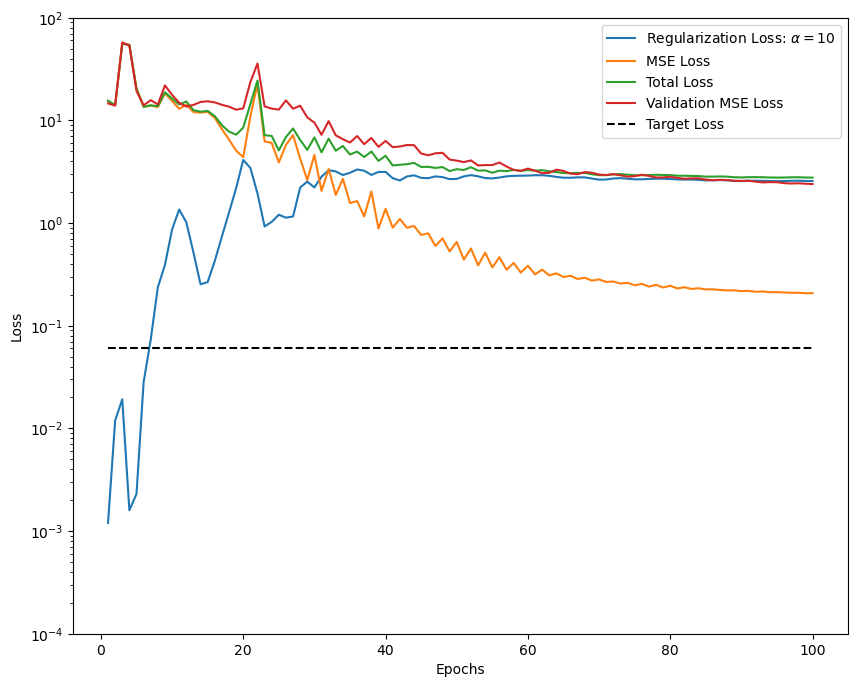

In [6]:
epoch = np.linspace(1,epochs,epochs)
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(epoch, np.array(losses['reg_losses'])/.06 ,label=fr'Regularization Loss: $\alpha ={alpha}$')
ax.plot(epoch, np.array(losses['mse_losses'])/.06 ,label='MSE Loss')
ax.plot(epoch, np.array(losses['total_losses'])/.06, label='Total Loss')
ax.plot(epoch, np.array(losses['mse_ver'])/.06, label='Validation MSE Loss')
ax.plot(epoch, .06*np.ones(epochs), 'k--', label='Target Loss')
ax.set_xlabel('Epochs')
ax.set_ylim(1e-4, 100)
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
plt.show()


### How many frames can we do??

- Add in 2 frames, 5 frames, and 10 frames to see if we can get good results

In [2]:
'Training Dataloader'

num_of_frames = 1
center_frame = 302
if num_of_frames %2 ==0:
    lb = center_frame -  num_of_frames//2
    ub = center_frame + num_of_frames//2
else:
    lb = center_frame - num_of_frames//2
    ub = center_frame + num_of_frames//2 +1

frames = [lb, ub, 1]

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))


1


In [3]:
'Testing Dataloader'

if num_of_frames %2 ==0:
    lb = center_frame -  num_of_frames//2
    ub = center_frame + num_of_frames//2
else:
    lb = center_frame - num_of_frames//2
    ub = center_frame + num_of_frames//2 +1

frames = [lb, ub, 1]

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)

In [4]:
epochs, alpha = [100, 5]

loss_curve = 'data/e_100_a_5_f1.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_e_100_a_5_f1.pt', ly =alpha, ver_dataloader = ver_dataloader )

torch.save(losses, loss_curve)

Epoch 0, Batch 0, Loss: 6.489744
Epoch 0 Complete - Avg Loss: 0.935493
Epoch 1, Batch 0, Loss: 0.935493
Epoch 1 Complete - Avg Loss: 5.112720
Epoch 2, Batch 0, Loss: 5.112720
Epoch 2 Complete - Avg Loss: 2.281924
Epoch 3, Batch 0, Loss: 2.281924
Epoch 3 Complete - Avg Loss: 1.190240
Epoch 4, Batch 0, Loss: 1.190240
Epoch 4 Complete - Avg Loss: 0.962374
Epoch 5, Batch 0, Loss: 0.962374
Epoch 5 Complete - Avg Loss: 0.848274
Epoch 6, Batch 0, Loss: 0.848274
Epoch 6 Complete - Avg Loss: 1.058682
Epoch 7, Batch 0, Loss: 1.058682
Epoch 7 Complete - Avg Loss: 1.230165
Epoch 8, Batch 0, Loss: 1.230165
Epoch 8 Complete - Avg Loss: 0.959837
Epoch 9, Batch 0, Loss: 0.959837
Epoch 9 Complete - Avg Loss: 0.732497
Epoch 10, Batch 0, Loss: 0.732497
Epoch 10 Complete - Avg Loss: 0.982175
Epoch 11, Batch 0, Loss: 0.982175
Epoch 11 Complete - Avg Loss: 0.633654
Epoch 12, Batch 0, Loss: 0.633654
Epoch 12 Complete - Avg Loss: 0.708708
Epoch 13, Batch 0, Loss: 0.708708
Epoch 13 Complete - Avg Loss: 0.59538

C:\Users\dculv\AppData\Local\Temp\ipykernel_27124\3078024396.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  losses = torch.load('data/e_10000_a_5.pt')


ValueError: x and y must have same first dimension, but have shapes (10000,) and (100,)

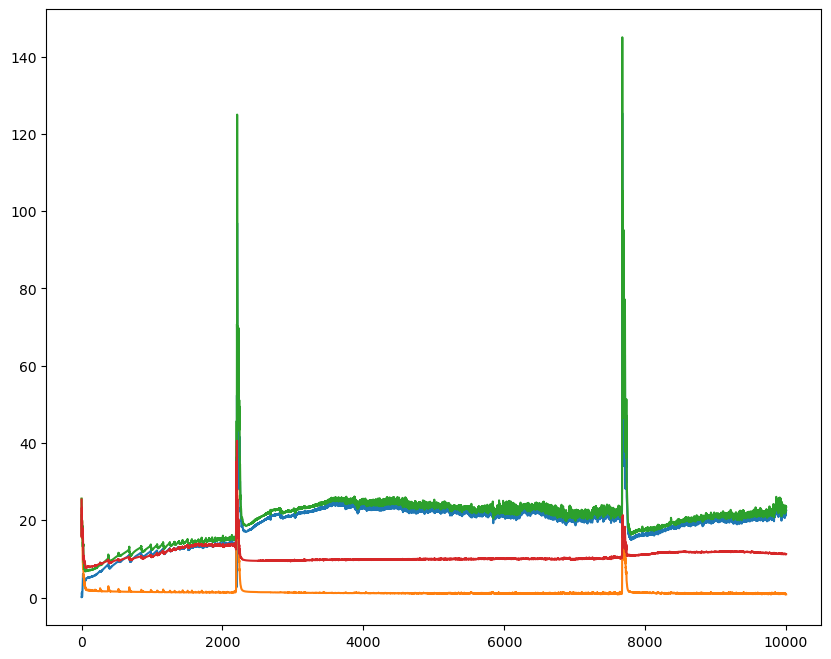

In [ ]:
losses = torch.load('data/e_10000_a_5.pt')
epoch = np.linspace(1,10000,10000)

train = np.sqrt(np.array(losses['mse_losses']))/.06
ver = np.sqrt(np.array(losses['mse_ver']))/.06
reg = np.sqrt(np.array(losses['reg_losses']))/.06
total = train + reg

fig, ax = plt.subplots(figsize=(10,8))
ax.plot(epoch, reg ,label=fr'Regularization Loss: $\alpha ={alpha}$')
ax.plot(epoch, train  ,label='MSE Loss')
ax.plot(epoch, total, label='Total Loss')
ax.plot(epoch, ver, label='Validation MSE Loss')
# ax.plot(epoch, 1*np.ones(epochs), 'k--', label='Target Loss')
ax.set_xlabel('Epochs')
ax.set_ylim(1e-4, 100)
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.legend()
plt.show()


### Simplify Training Procedure  (Modules Update)

In [ ]:
'Training Dataloader'
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(301,302, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)
print(len(spt_dataloader))

In [ ]:
'Testing Dataloader'

if num_of_frames %2 ==0:
    lb = center_frame -  num_of_frames//2
    ub = center_frame + num_of_frames//2
else:
    lb = center_frame - num_of_frames//2
    ub = center_frame + num_of_frames//2 +1

frames = [lb, ub, 1]

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(*frames)
device = 'cuda'

beams = [4,30]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)


dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
ver_dataloader = DataLoader(dataset, pin_memory=True,shuffle = True, num_workers=1, persistent_workers= True, batch_size=1)

In [ ]:
epochs, alpha = [100, 5]

loss_curve = 'data/e_100_a_5_f1.pt'

network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 1e-3 )

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

losses = retrainer.SPT_debugging(epochs, prints=True, saving= True,
                                  save_path='nets/SPT/spt_e_100_a_5_f1.pt', ly =alpha, ver_dataloader = ver_dataloader )

torch.save(losses, loss_curve)